#WHSIPER

In [ ]:
#  Step 1: Install Libraries 
!pip install -q librosa matplotlib ffmpeg-python soundfile
!pip install git+https://github.com/openai/whisper.git

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-61w6wq6q
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-61w6wq6q
  Resolved https://github.com/openai/whisper.git to commit 90db0de1896c23cbfaf0c58bc2d30665f709f170
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.6 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20240930-py3-none-any.whl size=803583 sha256=8ea37cbe4e18987764fcbe30ac0048a17c69329199420965332ba909dbf79ac4
  Stored in directory: /tmp/pip-ephem-wheel-cache-wyk5jvi0/wheels/8b/6c/d0/622666868c179f156cf595c8b6f06f88bc5d80c4b31dccaa03
Successfully built openai-whisper


Visualisasi sinyal asli:


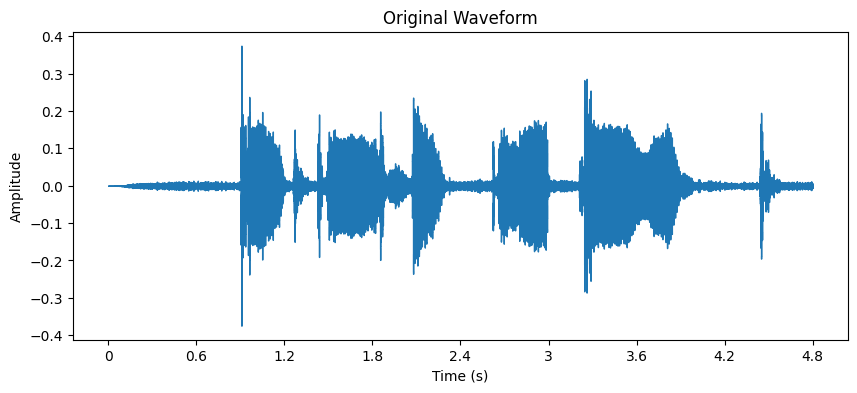


Transkripsi dari audio asli:


100%|███████████████████████████████████████| 139M/139M [00:01<00:00, 85.3MiB/s]
/usr/local/lib/python3.10/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper


Hasil Transkripsi:
 Aku suka bola

Memutar audio asli:


In [ ]:

#  Step 2: Import Libraries 
import librosa
import librosa.display
import matplotlib.pyplot as plt
import whisper
from IPython.display import Audio

#  Step 3: Define Functions 
def visualize_audio(file_path, title="Waveform"):
    "Visualize the waveform of an audio file."
    y, sr = librosa.load(file_path, sr=None)
    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()
    return y, sr

def transcribe_with_whisper(model, audio_path):
    "Transcribe audio using Whisper model."
    result = model.transcribe(audio_path, language="id")
    return result["text"]

#  Step 4: Load Audio and Visualize 
wav_test_file = "./Coba.wav"

print("Visualisasi sinyal asli:")
y_original, sr_original = visualize_audio(wav_test_file, title="Original Waveform")

#  Step 5: Transcribe Audio 
print("\nTranskripsi dari audio asli:")
model = whisper.load_model("base")
transcription = transcribe_with_whisper(model, wav_test_file)
print("\nHasil Transkripsi:")
print(transcription)

# Play the original audio
print("\nMemutar audio asli:")
display(Audio(wav_test_file, autoplay=True))

#LSTM

In [ ]:
pip install tensorflow noisereduce


In [ ]:
#  Step 1: Import Libraries 
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Masking
import pandas as pd
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#  Step 2: Define Paths 
wav_folder = "./wav suara"  # Path to WAV files
xlsx_folder = "./path"  # Path to transcriptions (Excel files)

In [ ]:
#  Step 3: Load Data 
audio_to_words = []

for file in os.listdir(xlsx_folder):
    if file.endswith('.xlsx'):
        df = pd.read_excel(os.path.join(xlsx_folder, file))
        for idx, row in df.iterrows():
            sentence = row['sentence']
            audio_path = os.path.join(wav_folder, row['path'])
            if os.path.exists(audio_path):
                words = sentence.split()  # Pecah kalimat menjadi kata
                for word in words:
                    audio_to_words.append((audio_path, word))

In [ ]:
#  Step 4: Extract Features 
def extract_features(file_path, n_mfcc=13, max_pad_len=500, denoise=False):
    "Extract MFCC features from an audio file."
    audio, sr = librosa.load(file_path, sr=None)
    if denoise:
        audio = denoise_audio(audio, sr)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    pad_width = max_pad_len - mfcc.shape[1]
    if pad_width > 0:
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

In [ ]:
#  Step 5: Noise Reduction 
def denoise_audio(audio, sr, noise_reduction_factor=0.01):
    "Apply noise reduction by thresholding low amplitude signals."
    noise_threshold = noise_reduction_factor * np.max(np.abs(audio))
    return np.where(np.abs(audio) > noise_threshold, audio, 0)

#  Step 6: Visualize Waveform 
def plot_waveform(audio, sr, title="Waveform"):
    "Plot audio waveform."
    plt.figure(figsize=(10, 4))
    plt.plot(np.linspace(0, len(audio) / sr, len(audio)), audio)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

In [ ]:
#  Step 7: Prepare Dataset 
X = []
y = []

for path, word in audio_to_words:
    features = extract_features(path)
    X.append(features)
    y.append(word)  # Simpan kata sebagai label

X = np.array(X)
y = np.array(y)

#  Step 8: Encode Labels 
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

#  Step 9: Split Data 
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [ ]:
#  Step 10: Build the Model 
input_dim = X.shape[2]
output_dim = len(label_encoder.classes_)

input_layer = Input(shape=(X.shape[1], input_dim))
masking_layer = Masking(mask_value=0)(input_layer)
lstm_layer = LSTM(128)(masking_layer)
output_layer = Dense(output_dim, activation='softmax')(lstm_layer)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
#  Step 11: Train the Model 
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=10
)

#  Step 12: Save the Model 
model.save("speech_recognition_model_per_word.h5")

#  Step 13: Evaluate the Model 
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Epoch 1/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 72s 67ms/step - accuracy: 0.0252 - loss: 7.5287 - val_accuracy: 0.0285 - val_loss: 7.1128
Epoch 2/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.0327 - loss: 6.5659 - val_accuracy: 0.0306 - val_loss: 6.8948
Epoch 3/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 85s 64ms/step - accuracy: 0.0410 - loss: 6.0058 - val_accuracy: 0.0316 - val_loss: 6.6758
Epoch 4/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 57s 60ms/step - accuracy: 0.0595 - loss: 5.4563 - val_accuracy: 0.0309 - val_loss: 6.5125
Epoch 5/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.0872 - loss: 4.9850 - val_accuracy: 0.0306 - val_loss: 6.3646
Epoch 6/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 59s 62ms/step - accuracy: 0.1096 - loss: 4.5835 - val_accuracy: 0.0357 - val_loss: 6.2521
Epoch 7/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 81s 61ms/step - accuracy: 0.1292 - loss: 4.2811 - val_accuracy: 0.0384 - val_loss: 6.1893
Epoch 8/10
948/948 ━━━━━━━━━━━━━━━━━━━━ 87s 66ms/step - accuracy: 0.1343 - loss: 4.0492 - 

237/237 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0417 - loss: 6.0921
Model Accuracy: 4.00%


Durasi Audio: 4.80 detik


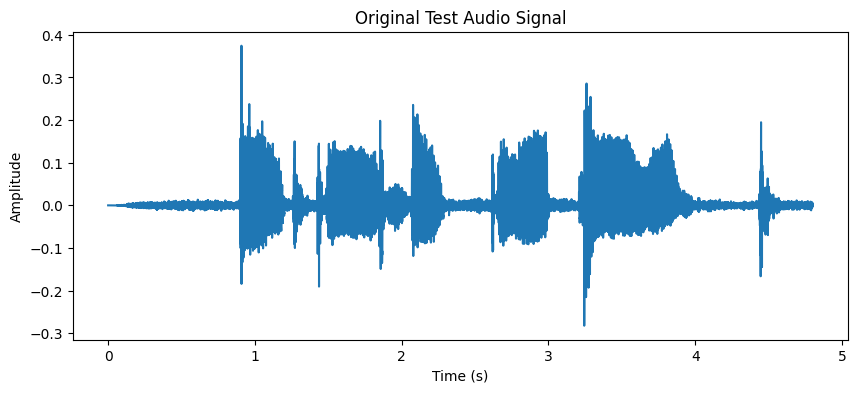

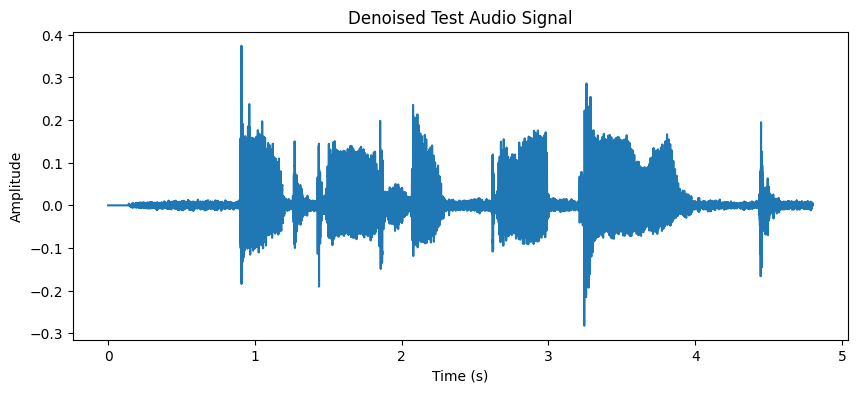

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step

Predicted Word: pada


In [ ]:
#  Step 14: Input File Audio untuk Prediksi 
test_audio_path = "./Coba.wav"  # Ganti dengan path file audio

#  Step 15: Fungsi untuk Prediksi 
def predict_and_visualize(file_path):
    "Prediksi kata dari audio dan visualisasi sinyal audio."
    # Load audio file
    audio, sr = librosa.load(file_path, sr=None)
    print(f"Durasi Audio: {len(audio) / sr:.2f} detik")

    # Visualisasi audio asli
    plot_waveform(audio, sr, "Original Test Audio Signal")

    # Denoise audio
    denoised_audio = denoise_audio(audio, sr)

    # Visualisasi audio setelah noise dihapus
    plot_waveform(denoised_audio, sr, "Denoised Test Audio Signal")

    # Ekstraksi fitur dari audio
    features = extract_features(file_path, denoise=True)
    features = np.expand_dims(features, axis=0)  # Tambahkan dimensi untuk prediksi

    # Prediksi label menggunakan model
    prediction = model.predict(features)
    predicted_label = label_encoder.inverse_transform([np.argmax(prediction)])

    # Output hasil prediksi
    print(f"\nPredicted Word: {predicted_label[0]}")

#  Step 16: Jalankan Prediksi 
predict_and_visualize(test_audio_path)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred.argmax(axis=1)))


237/237 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00         0
          20       0.00      0.00      0.00         1
          21       0.00      0.00      0.00         2
          24       0.00      0.00      0.00         1
          26       0.00      0.00      0.00         0
          27       0.33      1.00      0.50         1
          28       0.00      0.00      

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_